# ShortGPT: Layer Pruning via Block Influence
**CAP6614 - Efficient AI | Team 7**

This notebook implements the full ShortGPT pipeline:
1. Load Llama-2-7B in 4-bit quantization
2. Load WikiText-2 calibration data
3. Compute Block Influence (BI) scores for every layer
4. Visualize layer redundancy
5. Prune least-important layers
6. Evaluate: perplexity + generation quality

**Paper:** Men et al., *"ShortGPT: Layers in Large Language Models are More Redundant Than You Expect"* (arXiv 2403.03853)

## 0. Setup

Run this cell first on Colab. If running locally, `pip install -r requirements.txt` instead.

In [1]:
# Colab only - skip if running locally with requirements.txt installed
!pip install -q -U bitsandbytes transformers accelerate datasets sentencepiece protobuf matplotlib tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 127.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 150.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 55.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 7.34.0 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 7.34.0 which is incompatible

In [2]:
import random

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


---
## 1. Load Model in 4-bit Quantization

We use `bitsandbytes` NF4 quantization to fit Llama-2-7B into ~5 GB VRAM.

**Note:** `meta-llama/Llama-2-7b-hf` requires:
1. A HuggingFace account
2. Accepting Meta's license at https://huggingface.co/meta-llama/Llama-2-7b-hf
3. A HF token (set via `huggingface-cli login` or the cell below)

In [3]:
# Authenticate with HuggingFace (run once)
# Colab - will prompt for token
from huggingface_hub import login
login()

In [4]:
MODEL_ID = "meta-llama/Llama-2-7b-hf"

# 4-bit NF4 quantization config
# double_quant squeezes out a bit more memory savings on top of NF4
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading tokenizer from {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Llama doesn't set a pad token by default

print(f"Loading model in 4-bit NF4...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",          # let accelerate handle device placement
    torch_dtype=torch.bfloat16,
)
model.eval()  # inference only, no training

NUM_LAYERS = len(model.model.layers)
HIDDEN_DIM = model.config.hidden_size
print(f"\nModel loaded successfully!")
print(f"  Layers:     {NUM_LAYERS}")
print(f"  Hidden dim: {HIDDEN_DIM}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

Loading tokenizer from meta-llama/Llama-2-7b-hf...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]


Model loaded successfully!
  Layers:     32
  Hidden dim: 4096
  Parameters: 3.50B


---
## 2. Load Calibration Data (WikiText-2)

We sample random subsequences from the WikiText-2 training set.
This is the standard calibration approach used by SparseGPT, WANDA, and ShortGPT.

In [5]:
SEQLEN = 512       # tokens per sample (512 works on T4; paper uses 2048)
NSAMPLES = 128     # number of calibration samples (standard for SparseGPT/WANDA)


def get_wikitext2_calibration(nsamples, seqlen, tokenizer, seed=42):
    """Load WikiText-2 and return calibration samples + test encoding."""
    traindata = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
    testdata = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")

    # Added filter to not waste tokens and skew distribution
    train_text = " ".join([t for t in traindata["text"] if t and t.strip()])
    test_text  = "\n\n".join([t for t in testdata["text"] if t and t.strip()])

    # Concat all training text into one long string, then tokenize it all at once
    trainenc = tokenizer(train_text, return_tensors="pt", truncation=False)
    testenc  = tokenizer(test_text,  return_tensors="pt", truncation=False)

    # trainenc = tokenizer(
    #     " ".join(traindata["text"]),
    #     return_tensors="pt",
    # )
    # testenc = tokenizer(
    #     "\n\n".join(testdata["text"]),
    #     return_tensors="pt",
    # )

    # Grab random windows from the tokenized training data
    random.seed(seed)
    samples = []
    for _ in range(nsamples):
        i = random.randint(0, trainenc.input_ids.shape[1] - seqlen - 1)
        samples.append(trainenc.input_ids[:, i : i + seqlen])  # shape: (1, seqlen)

    return samples, testenc, trainenc.input_ids.shape[1], testenc.input_ids.shape[1]


print("Loading WikiText-2...")
calibration_data, test_encoding, train_tokens, test_tokens = get_wikitext2_calibration(
    NSAMPLES, SEQLEN, tokenizer, seed=SEED
)
print(f"Calibration: {len(calibration_data)} samples x {SEQLEN} tokens")
print(f"Test set: {test_encoding.input_ids.shape[1]} tokens")

Loading WikiText-2...


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Calibration: 128 samples x 512 tokens
Test set: 338534 tokens


---
## 3. Block Influence (BI) Metric

For each layer *i*, Block Influence measures how much the layer changes
the hidden state passing through it:

$$\text{BI}_i = 1 - \mathbb{E}_{X,t}\left[\frac{X_{i,t}^\top \cdot X_{i+1,t}}{\|X_{i,t}\| \cdot \|X_{i+1,t}\|}\right]$$

- **BI close to 0** = layer barely changes anything (redundant, safe to remove)
- **BI close to 1** = layer makes big changes to the hidden state (important, keep it)

In [6]:
def block_influence(x_in, x_out):
    """Compute per-token Block Influence between layer input and output.
    BI = 1 - cosine_sim(input, output). Returns (B*S,) tensor of scores in [0,1].
    """
    B, S, D = x_in.shape

    # Flatten batch + sequence dims so we get one cosine sim value per token
    flat_in = x_in.reshape(-1, D).float()
    flat_out = x_out.reshape(-1, D).float()

    sim = F.cosine_similarity(flat_in, flat_out, dim=-1)  # shape: (B*S,)
    sim = sim.nan_to_num(nan=0.5)  # safety net for zero-norm edge cases
    return 1.0 - sim

---
## 4. Compute BI Scores Across All Layers

We forward-pass all calibration samples through the model with `output_hidden_states=True`.
This gives us the hidden state at every layer boundary without needing manual hooks.

`hidden_states[i]` = input to layer `i`, `hidden_states[i+1]` = output of layer `i`.

In [7]:
def compute_bi_scores(model, calibration_data, num_layers):
    """Compute average BI score for every layer across all calibration samples."""
    bi_scores = [0.0] * num_layers
    total_tokens = 0

    with torch.no_grad():
        for inp in tqdm(calibration_data, desc="Computing BI scores"):
            outputs = model(
                input_ids=inp.to(DEVICE),
                output_hidden_states=True,  # this gives us hidden states at every layer
                use_cache=False,
                return_dict=True,
            )
            # hidden_states is a tuple of (num_layers + 1) tensors
            # hidden_states[i] = input to layer i
            # hidden_states[i+1] = output of layer i
            hidden_states = outputs.hidden_states
            n_tokens = inp.shape[1]
            total_tokens += n_tokens

            for i in range(num_layers):
                bi = block_influence(hidden_states[i], hidden_states[i + 1])
                bi_scores[i] += bi.sum().item()

    # Average over all tokens across all samples
    bi_scores = [s / total_tokens for s in bi_scores]
    return bi_scores


print(f"Running {NSAMPLES} calibration samples through {NUM_LAYERS} layers...")
bi_scores = compute_bi_scores(model, calibration_data, NUM_LAYERS)

print("\nBlock Influence scores per layer:")
for i, score in enumerate(bi_scores):
    bar = "█" * int(score * 100)
    print(f"  Layer {i:2d}: {score:.4f}  {bar}")

Running 128 calibration samples through 32 layers...


Computing BI scores: 100%|██████████| 128/128 [00:14<00:00,  8.56it/s]


Block Influence scores per layer:
  Layer  0: 0.3985  ███████████████████████████████████████
  Layer  1: 0.2517  █████████████████████████
  Layer  2: 0.1855  ██████████████████
  Layer  3: 0.1530  ███████████████
  Layer  4: 0.1592  ███████████████
  Layer  5: 0.1587  ███████████████
  Layer  6: 0.1529  ███████████████
  Layer  7: 0.1467  ██████████████
  Layer  8: 0.1393  █████████████
  Layer  9: 0.1306  █████████████
  Layer 10: 0.1231  ████████████
  Layer 11: 0.1100  ██████████
  Layer 12: 0.1078  ██████████
  Layer 13: 0.1083  ██████████
  Layer 14: 0.1034  ██████████
  Layer 15: 0.1066  ██████████
  Layer 16: 0.1062  ██████████
  Layer 17: 0.0866  ████████
  Layer 18: 0.0761  ███████
  Layer 19: 0.0645  ██████
  Layer 20: 0.0654  ██████
  Layer 21: 0.0493  ████
  Layer 22: 0.0480  ████
  Layer 23: 0.0406  ████
  Layer 24: 0.0373  ███
  Layer 25: 0.0384  ███
  Layer 26: 0.0367  ███
  Layer 27: 0.0352  ███
  Layer 28: 0.0383  ███
  Layer 29: 0.0400  ███
  Layer 30: 0.0653  ████

---
## 5. Visualize Layer Importance

This reproduces **Figure 3** from the ShortGPT paper, the layer importance plot.
Expect to see: first few layers and the last layer have high BI; middle-to-later layers are redundant.

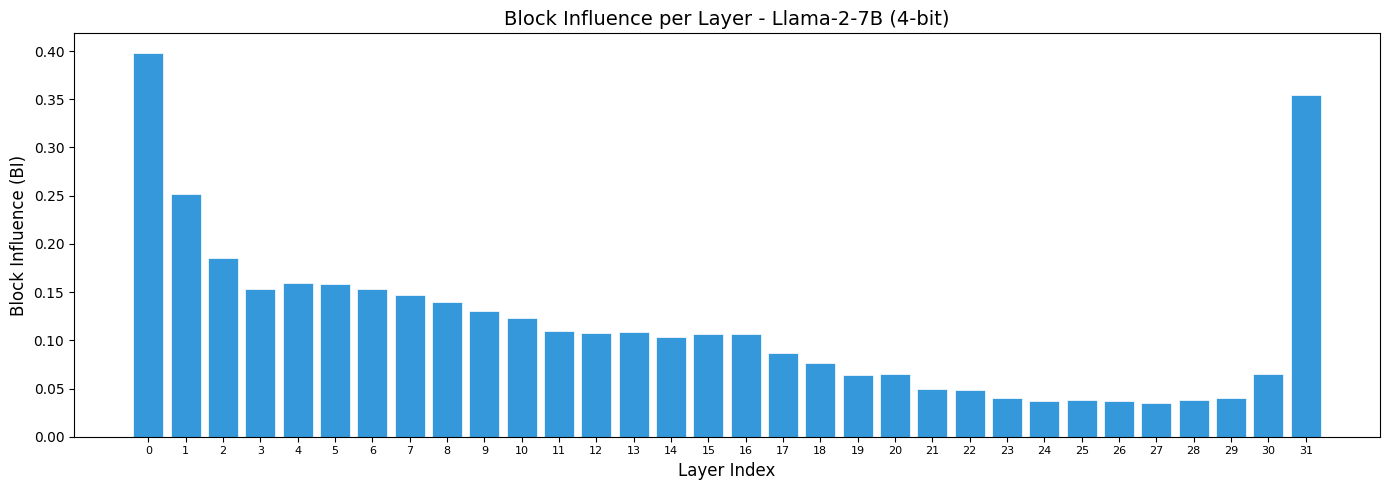

Saved: bi_scores.png

Most redundant layers (lowest BI):  [27, 26, 24, 28, 25]
Most critical layers (highest BI):   [4, 2, 1, 31, 0]


In [8]:
def plot_bi_scores(bi_scores, model_name="Llama-2-7B (4-bit)", n_prune=None):
    """Bar chart of BI scores per layer, with optional pruning threshold."""
    fig, ax = plt.subplots(figsize=(14, 5))

    layers = list(range(len(bi_scores)))

    # Color bars: red = will be pruned, blue = kept
    if n_prune is not None:
        prune_set = set(np.argsort(bi_scores)[:n_prune])
        colors = ["#e74c3c" if i in prune_set else "#3498db" for i in layers]
    else:
        colors = "#3498db"

    ax.bar(layers, bi_scores, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Layer Index", fontsize=12)
    ax.set_ylabel("Block Influence (BI)", fontsize=12)
    ax.set_title(f"Block Influence per Layer - {model_name}", fontsize=14)
    ax.set_xticks(layers)
    ax.set_xticklabels(layers, fontsize=8)

    if n_prune is not None:
        # Add threshold line
        threshold = sorted(bi_scores)[n_prune]
        ax.axhline(y=threshold, color="#e74c3c", linestyle="--", alpha=0.7,
                   label=f"Pruning threshold (remove {n_prune} layers)")
        ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig("bi_scores.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: bi_scores.png")


# Plot without pruning threshold first
plot_bi_scores(bi_scores)

# Identify most and least important layers
ranked = np.argsort(bi_scores)
print(f"\nMost redundant layers (lowest BI):  {ranked[:5].tolist()}")
print(f"Most critical layers (highest BI):   {ranked[-5:].tolist()}")

---
## 5.5 Baseline Perplexity (Before Pruning)

We need the unpruned model's perplexity so we have something to compare against after pruning.
**Run this before the pruning step.**

In [9]:
def load_fresh_model():
    """
    Load a fresh unmodified copy of the model.
    """
    fresh_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.bfloat16,
    )
    fresh_model.eval()
    return fresh_model


@torch.no_grad()
def evaluate_nll_and_ppl_sliding(model, test_encoding, max_length=1024, stride=512):
    """
    Standard sliding-window evaluation.
    Returns both average NLL and perplexity.
    """
    model.eval()

    input_ids = test_encoding.input_ids.to(DEVICE)
    seq_len = input_ids.size(1)

    nlls = []
    total_tokens = 0
    prev_end = 0

    for begin in tqdm(range(0, seq_len, stride), desc="Evaluating PPL (sliding)"):
        end = min(begin + max_length, seq_len)
        trg_len = end - prev_end

        input_slice = input_ids[:, begin:end]
        labels = input_slice.clone()

        # Only score newly introduced tokens
        if trg_len < input_slice.size(1):
            labels[:, :-trg_len] = -100

        outputs = model(
            input_ids=input_slice,
            labels=labels,
            use_cache=False,
            return_dict=True,
        )

        num_valid_tokens = (labels != -100).sum().item()
        nlls.append(outputs.loss.float() * num_valid_tokens)
        total_tokens += num_valid_tokens
        prev_end = end

        if end == seq_len:
            break

    avg_nll = (torch.stack(nlls).sum() / total_tokens).item()
    ppl = float(torch.exp(torch.tensor(avg_nll)))
    return avg_nll, ppl

In [10]:
print("Loading fresh UNPRUNED model for baseline evaluation...")
baseline_model = load_fresh_model()

print("Evaluating BASELINE (unpruned) perplexity on WikiText-2 test set...")
baseline_nll, baseline_ppl = evaluate_nll_and_ppl_sliding(
    baseline_model,
    test_encoding,
    max_length=1024,
    stride=512
)

print(f"\nBaseline NLL (unpruned): {baseline_nll:.10f}")
print(f"Baseline PPL (unpruned): {baseline_ppl:.10f}")
print("(For reference: original Llama-2-7B PPL on WikiText-2 is around 5.5)")

Loading fresh UNPRUNED model for baseline evaluation...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Evaluating BASELINE (unpruned) perplexity on WikiText-2 test set...


Evaluating PPL (sliding): 100%|█████████▉| 660/662 [01:10<00:00,  9.38it/s]


Baseline NLL (unpruned): 1.6748824120
Baseline PPL (unpruned): 5.3381671906
(For reference: original Llama-2-7B PPL on WikiText-2 is around 5.5)


---
## 6. Layer Removal

Remove the least important layers from `model.model.layers`. A few things to watch out for:
- Delete layers in **reverse index order** so the indices don't shift as you go
- **Re-index** `self_attn.layer_idx` on the remaining layers, otherwise the KV cache breaks
- **Update** `model.config.num_hidden_layers` so saving/loading the model still works

In [11]:
PRUNE_VALUES = [0, 2, 4, 6, 8]
results = []
pruned_models = {}

In [12]:
def remove_layers(model, bi_scores, n_prune):
    """
    Remove the n_prune layers with the lowest BI scores (most redundant).
    Returns a sorted list of removed layer indices.
    """
    if n_prune == 0:
        return []

    layers_to_remove = np.argsort(bi_scores)[:n_prune].tolist()
    print(f"Removing {n_prune} layers: {sorted(layers_to_remove)}")

    for idx in sorted(layers_to_remove, reverse=True):
        del model.model.layers[idx]

    for new_idx, layer in enumerate(model.model.layers):
        layer.self_attn.layer_idx = new_idx

    model.config.num_hidden_layers = len(model.model.layers)
    return sorted(layers_to_remove)

In [13]:
print("=" * 70)
print("AUTOMATED PRUNING SWEEP")
print("=" * 70)

# Store baseline as the 0-pruning row
results.append({
    "n_prune": 0,
    "remaining_layers": NUM_LAYERS,
    "removed_layers": [],
    "baseline_nll": baseline_nll,
    "pruned_nll": baseline_nll,
    "nll_increase": 0.0,
    "baseline_ppl": baseline_ppl,
    "pruned_ppl": baseline_ppl,
    "ppl_increase": 0.0,
    "percent_increase": 0.0,
})

AUTOMATED PRUNING SWEEP



Running pruning experiment for N_PRUNE = 2


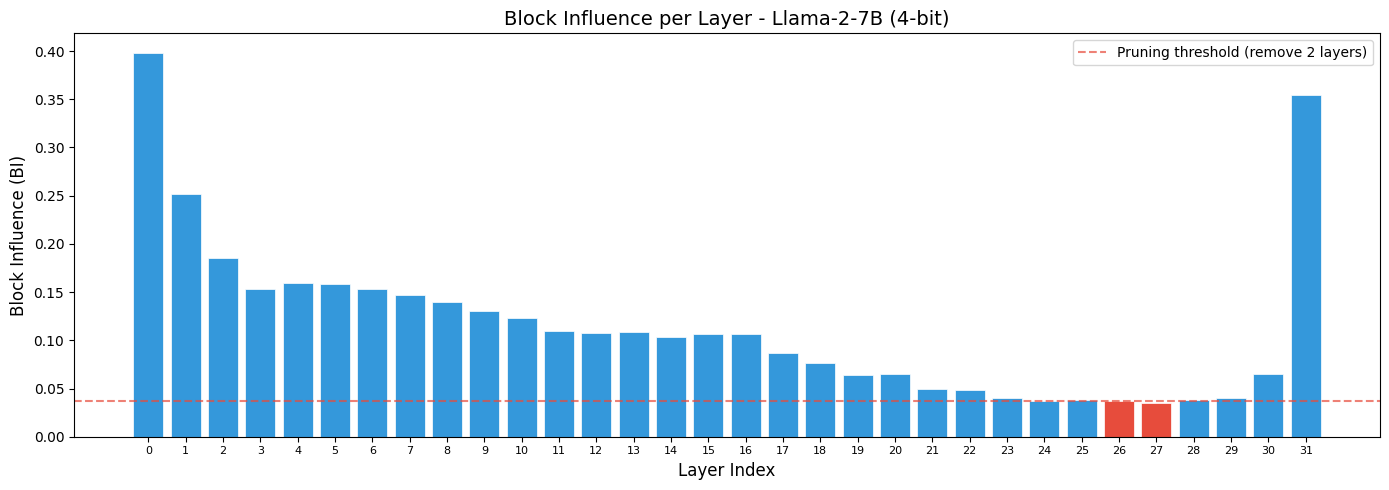

Saved: bi_scores.png


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Removing 2 layers: [26, 27]
Pruned model now has 30 layers.


Evaluating PPL (sliding): 100%|█████████▉| 660/662 [01:05<00:00, 10.03it/s]



Baseline NLL: 1.6748824120
Pruned NLL:   1.8198523521
NLL increase: 0.1449699402

Baseline PPL: 5.3381671906
Pruned PPL:   6.1709470749
PPL increase: 0.8327798843
Percent increase: 15.600483%

Running pruning experiment for N_PRUNE = 4


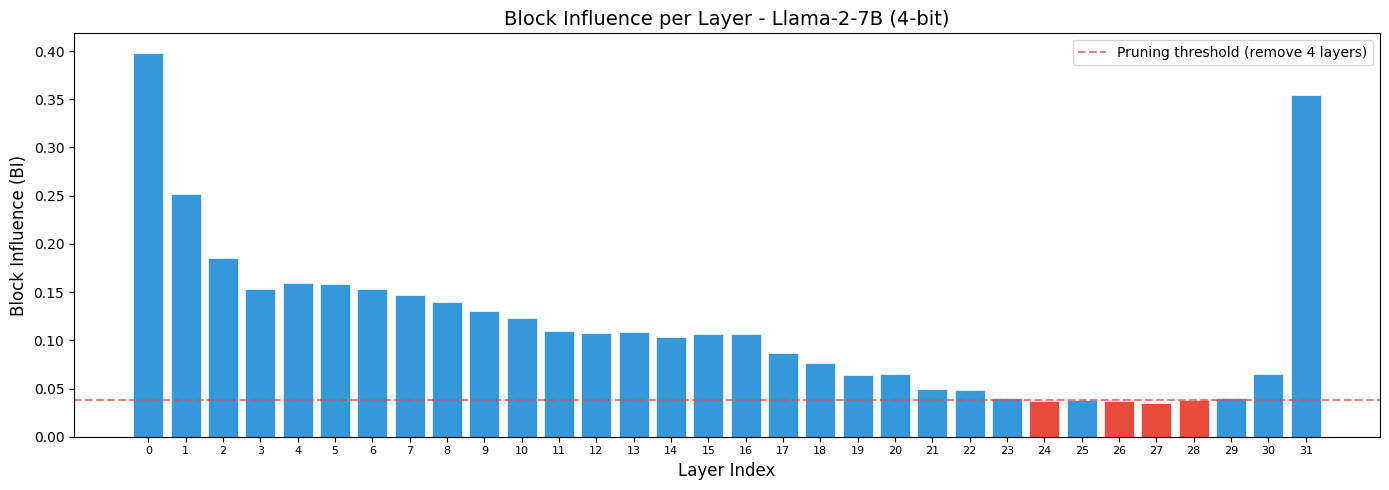

Saved: bi_scores.png


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Removing 4 layers: [24, 26, 27, 28]
Pruned model now has 28 layers.


Evaluating PPL (sliding): 100%|█████████▉| 660/662 [01:01<00:00, 10.73it/s]



Baseline NLL: 1.6748824120
Pruned NLL:   2.1272218227
NLL increase: 0.4523394108

Baseline PPL: 5.3381671906
Pruned PPL:   8.3915214539
PPL increase: 3.0533542633
Percent increase: 57.198551%

Running pruning experiment for N_PRUNE = 6


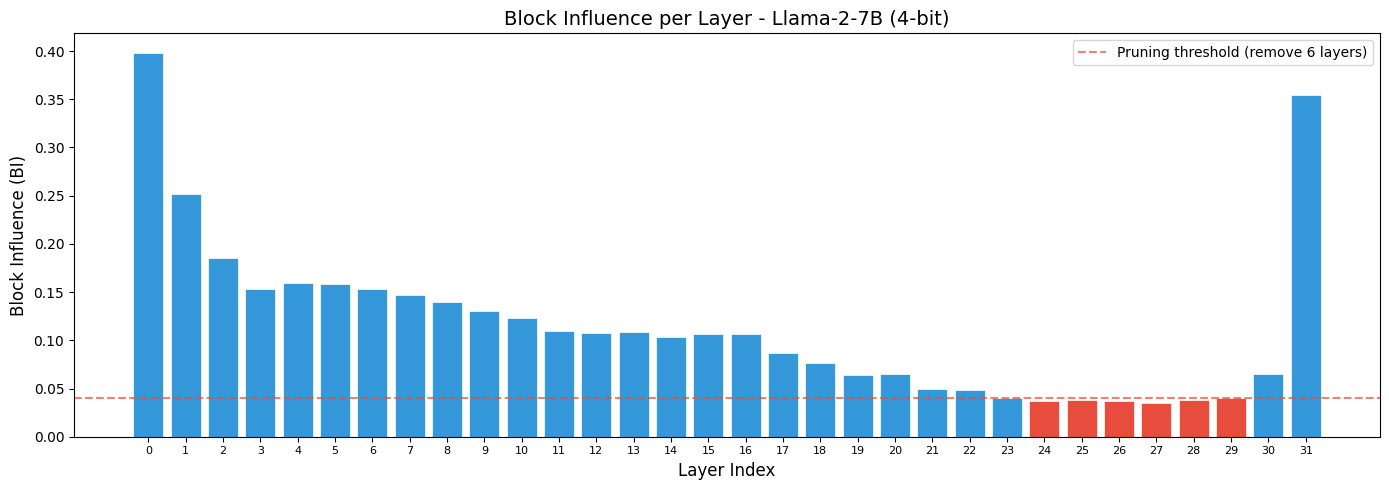

Saved: bi_scores.png


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Removing 6 layers: [24, 25, 26, 27, 28, 29]
Pruned model now has 26 layers.


Evaluating PPL (sliding): 100%|█████████▉| 660/662 [00:57<00:00, 11.53it/s]



Baseline NLL: 1.6748824120
Pruned NLL:   2.7288484573
NLL increase: 1.0539660454

Baseline PPL: 5.3381671906
Pruned PPL:   15.3152408600
PPL increase: 9.9770736694
Percent increase: 186.900734%

Running pruning experiment for N_PRUNE = 8


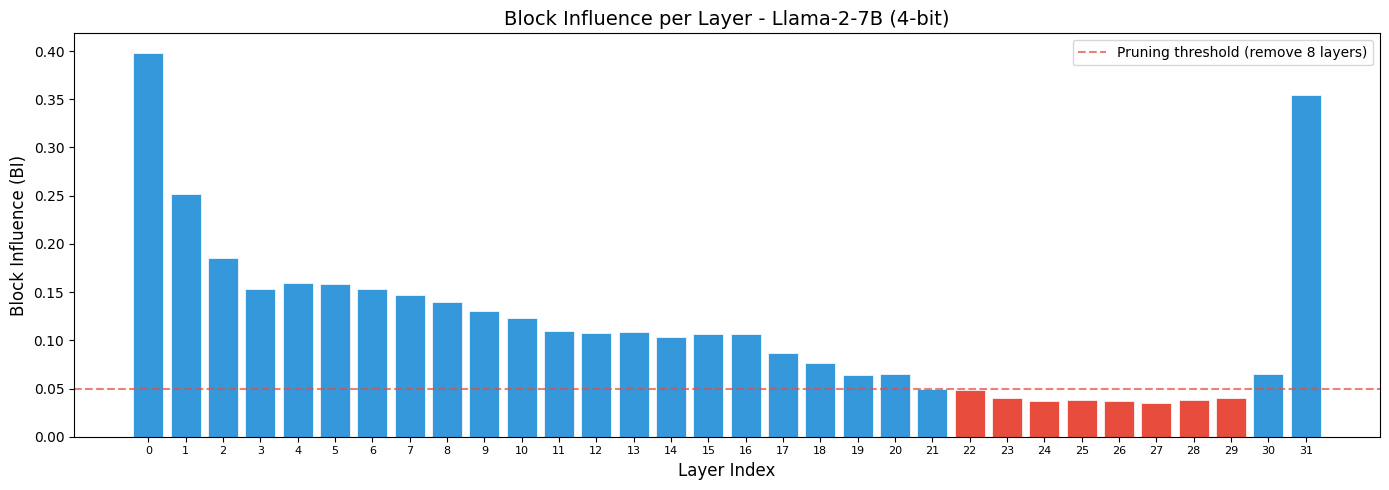

Saved: bi_scores.png


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Removing 8 layers: [22, 23, 24, 25, 26, 27, 28, 29]
Pruned model now has 24 layers.


Evaluating PPL (sliding): 100%|█████████▉| 660/662 [00:53<00:00, 12.43it/s]


Baseline NLL: 1.6748824120
Pruned NLL:   3.2295656204
NLL increase: 1.5546832085

Baseline PPL: 5.3381671906
Pruned PPL:   25.2686786652
PPL increase: 19.9305114746
Percent increase: 373.358697%


In [14]:
for n_prune in PRUNE_VALUES:
    if n_prune == 0:
        continue

    print("\n" + "=" * 70)
    print(f"Running pruning experiment for N_PRUNE = {n_prune}")
    print("=" * 70)

    plot_bi_scores(bi_scores, n_prune=n_prune)

    pruned_model = load_fresh_model()
    removed = remove_layers(pruned_model, bi_scores, n_prune)

    print(f"Pruned model now has {len(pruned_model.model.layers)} layers.")

    pruned_nll, pruned_ppl = evaluate_nll_and_ppl_sliding(
        pruned_model,
        test_encoding,
        max_length=1024,
        stride=512
    )

    nll_increase = pruned_nll - baseline_nll
    ppl_increase = pruned_ppl - baseline_ppl
    percent_increase = (ppl_increase / baseline_ppl) * 100

    print(f"\nBaseline NLL: {baseline_nll:.10f}")
    print(f"Pruned NLL:   {pruned_nll:.10f}")
    print(f"NLL increase: {nll_increase:.10f}")

    print()

    print(f"Baseline PPL: {baseline_ppl:.10f}")
    print(f"Pruned PPL:   {pruned_ppl:.10f}")
    print(f"PPL increase: {ppl_increase:.10f}")
    print(f"Percent increase: {percent_increase:.6f}%")

    results.append({
        "n_prune": n_prune,
        "remaining_layers": NUM_LAYERS - n_prune,
        "removed_layers": removed,
        "baseline_nll": baseline_nll,
        "pruned_nll": pruned_nll,
        "nll_increase": nll_increase,
        "baseline_ppl": baseline_ppl,
        "pruned_ppl": pruned_ppl,
        "ppl_increase": ppl_increase,
        "percent_increase": percent_increase,
    })

    # optionally keep model in memory for later generation/save
    # pruned_models[n_prune] = pruned_model

    # free memory before next iteration
    del pruned_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


---
## 7. Evaluate Pruned Model Perplexity

Now we run the same perplexity evaluation on the pruned model.
Compare this against the baseline we computed in section 5.5.

In [15]:
## 7. Results Table

print("\n" + "=" * 90)
print("PRUNING RESULTS SUMMARY")
print("=" * 90)
print(f"{'Removed':<10} {'Remain':<10} {'PPL':<14} {'ΔPPL':<14} {'% Increase':<14}")
print("-" * 90)

for r in results:
    print(f"{r['n_prune']:<10} "
          f"{r['remaining_layers']:<10} "
          f"{r['pruned_ppl']:<14.6f} "
          f"{r['ppl_increase']:<14.6f} "
          f"{r['percent_increase']:<14.2f}")


PRUNING RESULTS SUMMARY
Removed    Remain     PPL            ΔPPL           % Increase    
------------------------------------------------------------------------------------------
0          32         5.338167       0.000000       0.00          
2          30         6.170947       0.832780       15.60         
4          28         8.391521       3.053354       57.20         
6          26         15.315241      9.977074       186.90        
8          24         25.268679      19.930511      373.36        


In [16]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,n_prune,remaining_layers,removed_layers,baseline_nll,pruned_nll,nll_increase,baseline_ppl,pruned_ppl,ppl_increase,percent_increase
0,0,32,[],1.674882,1.674882,0.000000,5.338167,5.338167,0.000000,0.000000
1,2,30,"[26, 27]",1.674882,1.819852,0.144970,5.338167,6.170947,0.832780,15.600483
2,4,28,"[24, 26, 27, 28]",1.674882,2.127222,0.452339,5.338167,8.391521,3.053354,57.198551
3,6,26,"[24, 25, 26, 27, 28, 29]",1.674882,2.728848,1.053966,5.338167,15.315241,9.977074,186.900734
4,8,24,"[22, 23, 24, 25, 26, 27, 28, 29]",1.674882,3.229566,1.554683,5.338167,25.268679,19.930511,373.358697


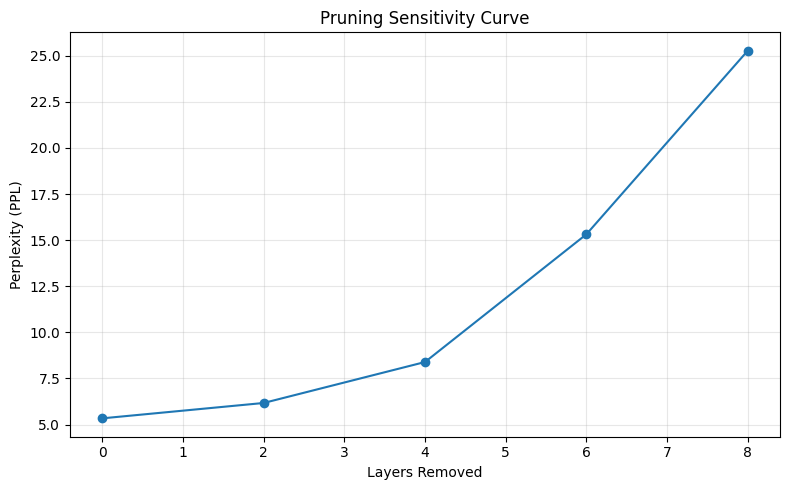

Saved: pruning_sensitivity_curve.png


In [17]:
layers_removed = [r["n_prune"] for r in results]
ppls = [r["pruned_ppl"] for r in results]

plt.figure(figsize=(8, 5))
plt.plot(layers_removed, ppls, marker="o")
plt.xlabel("Layers Removed")
plt.ylabel("Perplexity (PPL)")
plt.title("Pruning Sensitivity Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pruning_sensitivity_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: pruning_sensitivity_curve.png")

---
## 8. Evaluate: Generation Quality (Sanity Check)

Quick qualitative test - does the pruned model still produce coherent text?

In [18]:
def generate_text(model, tokenizer, prompt, max_new_tokens=100):
    """Quick helper to generate text from a prompt."""
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

In [19]:
# A few test prompts to see if the pruned model still makes sense
GEN_N_PRUNE = 2  # choose which pruning level to inspect qualitatively

print(f"Loading fresh model for generation test at N_PRUNE = {GEN_N_PRUNE}...")
gen_model = load_fresh_model()
_ = remove_layers(gen_model, bi_scores, GEN_N_PRUNE)

test_prompts = [
    "The theory of relativity states that",
    "In a large neural network, the deeper layers",
    "The capital of France is",
]

print("=" * 70)
print(f"GENERATION SAMPLES FOR N_PRUNE = {GEN_N_PRUNE}")
print("=" * 70)

for prompt in test_prompts:
    output = generate_text(gen_model, tokenizer, prompt)
    print(f"\nPrompt: {prompt}")
    print(f"Output: {output}")
    print("-" * 70)

Loading fresh model for generation test at N_PRUNE = 2...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Removing 2 layers: [26, 27]
GENERATION SAMPLES FOR N_PRUNE = 2


Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: The theory of relativity states that
Output: The theory of relativity states that the speed of light is constant in all frames of reference.➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖
📅 2018 📚 University of Cambridge 📝 The Theory of Relativity 📙 A. Einstein
📖 "We have all heard of a struggle for existence,
----------------------------------------------------------------------


Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: In a large neural network, the deeper layers
Output: In a large neural network, the deeper layers of neurons have more weights than the surface-level layers. Begriffe, die zu „Neuron“ gehören. The neuron is the basic functional unit of the nervous system. A neuron is a cell that is specialized for signaling. Neurons are specialized cells that can transmit electrical signals to other cells. A neuron is a cell in the nervous system. Neuroscientists have found that the brain is organized as a network of these cells.
----------------------------------------------------------------------

Prompt: The capital of France is
Output: The capital of France is a wonderful city, with great food, amazing architecture, and a rich history. kwiet 2022 ... The Eiffel Tower is the most famous symbol of Paris. ... The Louvre is one of the most famous art museums in the world.
Paris is a beautiful city. It has a lot of amazing things to see and do. One of the most famous things to see in Paris is 

In [20]:
# Optional cleanup of cache
del gen_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

---
## 9. Save Pruned Model (Optional)

Save the pruned model so the team can load it directly without re-running pruning.

In [21]:
# Uncomment to save
# SAVE_N_PRUNE = 2  # choose which pruned model to save

# SAVE_DIR = f"llama2-7b-shortgpt-pruned-{SAVE_N_PRUNE}layers"
# pruned_models[SAVE_N_PRUNE].save_pretrained(SAVE_DIR)
# tokenizer.save_pretrained(SAVE_DIR)
# print(f"Saved pruned model to {SAVE_DIR}/")

NameError: name 'pruned_models' is not defined

---
## 10. Summary Table

Print a clean results summary for the report.

In [ ]:
# print("\n" + "=" * 50)
# print("RESULTS SUMMARY")
# print("=" * 50)
# print(f"Model:              {MODEL_ID}")
# print(f"Quantization:       4-bit NF4 (double quant)")
# print(f"Original layers:    {NUM_LAYERS}")
# print(f"Pruned layers:      {N_PRUNE} ({N_PRUNE/NUM_LAYERS*100:.0f}%)")
# print(f"Remaining layers:   {NUM_LAYERS - N_PRUNE}")
# print(f"Layers removed:     {removed}")
# print(f"Calibration:        WikiText-2, {NSAMPLES} samples x {SEQLEN} tokens")
# print(f"Baseline PPL:       {baseline_ppl:.2f}")
# print(f"Pruned model PPL:   {pruned_ppl:.2f}")
# print(f"PPL increase:       {pruned_ppl - baseline_ppl:.2f} ({((pruned_ppl - baseline_ppl) / baseline_ppl) * 100:.1f}%)")
# print("=" * 50)

In [22]:
import json, time, transformers, datasets, platform

run_summary = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "model": MODEL_ID,
    "quant": "4bit_nf4_double",
    "seqlen_calib": SEQLEN,
    "nsamples_calib": NSAMPLES,
    "ppl_max_length": 1024,
    "ppl_stride": 512,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "datasets": datasets.__version__,
    "python": platform.python_version(),
    "results": results,
}

with open("pruning_results.json", "w") as f:
    json.dump(run_summary, f, indent=2)

print("Saved pruning_results.json")

Saved pruning_results.json
